**Data Gathering**

In [ ]:
import os

project_path = "/content/drive/MyDrive/clear_vision"

folders = [
    "data/train",
    "data/val",
    "data/test",
    "data/train_patches",
    "data/val_patches",
    "models",
    "corruption",
    "outputs",
    "app"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Folder structure created successfully!")

In [ ]:
!wget http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip
!unzip DIV2K_train_HR.zip

In [ ]:
import os
import shutil
import random

source = "DIV2K_train_HR"
images = os.listdir(source)

random.shuffle(images)

train_imgs = images[:700]
val_imgs = images[700:750]
test_imgs = images[750:800]

base_path = "/content/drive/MyDrive/clear_vision/data"

for img in train_imgs:
    shutil.copy(os.path.join(source, img), os.path.join(base_path, "train"))

for img in val_imgs:
    shutil.copy(os.path.join(source, img), os.path.join(base_path, "val"))

for img in test_imgs:
    shutil.copy(os.path.join(source, img), os.path.join(base_path, "test"))

print("Dataset split complete!")

In [ ]:
from PIL import Image
import os

def create_patches(input_folder, output_folder, patch_size=256):
    os.makedirs(output_folder, exist_ok=True)

    image_files = os.listdir(input_folder)

    for img_name in image_files:
        img_path = os.path.join(input_folder, img_name)
        img = Image.open(img_path).convert("RGB")
        width, height = img.size

        patch_count = 0

        for i in range(0, width - patch_size + 1, patch_size):
            for j in range(0, height - patch_size + 1, patch_size):
                patch = img.crop((i, j, i + patch_size, j + patch_size))
                patch.save(os.path.join(output_folder, f"{img_name}_{patch_count}.png"))
                patch_count += 1

    print(f"Patches created in {output_folder}")

In [ ]:
create_patches("train", "train_patches", patch_size=256)
create_patches("val", "val_patches", patch_size=256)

In [1]:
import os

os.listdir("/kaggle/input")

['datasets']

In [2]:
os.listdir("/kaggle/input/datasets/anurajgogoi/clear-vision-dataset/clear_vision_datasets")

['train_patches', 'val_patches']

In [2]:
train_dir = "/kaggle/input/datasets/anurajgogoi/clear-vision-dataset/clear_vision_datasets/train_patches"
val_dir = "/kaggle/input/datasets/anurajgogoi/clear-vision-dataset/clear_vision_datasets/val_patches"

print("Train images:", len(os.listdir(train_dir)))
print("Val images:", len(os.listdir(val_dir)))

Train images: 24477
Val images: 1722


In [3]:
import os

print(len(os.listdir(train_dir)))
print(len(os.listdir(val_dir)))

24477
1722


**Adding noise to clean dataset**

In [4]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [6]:
from torch.utils.data import Dataset
from PIL import Image
import torch

def add_gaussian_noise(image):
    noise = torch.randn_like(image) * 0.1
    noisy = image + noise
    return torch.clamp(noisy,0,1)

class ImageDataset(Dataset):

    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.images = os.listdir(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        path = os.path.join(self.image_dir, self.images[idx])
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        corrupted = add_gaussian_noise(image)

        return corrupted, image

In [7]:
train_dataset = ImageDataset(train_dir, transform)
val_dataset = ImageDataset(val_dir, transform)

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [9]:
import torch
print(torch.cuda.is_available())

True


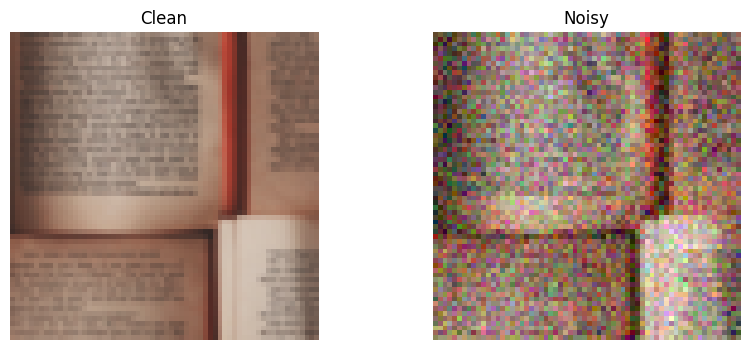

In [10]:
import matplotlib.pyplot as plt

noisy, clean = next(iter(train_loader))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(clean[0].permute(1,2,0))
plt.title("Clean")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy[0].permute(1,2,0))
plt.title("Noisy")
plt.axis("off")

plt.show()

*Model Training*

**simple autoencoder model**

In [10]:
import torch
import torch.nn as nn

class SimpleAutoencoder(nn.Module):
    def __init__(self):
        super(SimpleAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128x128

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 64x64
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),  # 128x128
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2),   # 256x256
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleAutoencoder().to(device)
print("Model loaded on:", device)

Model loaded on: cuda


In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [13]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for noisy, clean in train_loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        outputs = model(noisy)
        loss = criterion(outputs, clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.6f}")

Epoch [1/20], Loss: 0.006933
Epoch [2/20], Loss: 0.003677
Epoch [3/20], Loss: 0.003336
Epoch [4/20], Loss: 0.003139
Epoch [5/20], Loss: 0.002983
Epoch [6/20], Loss: 0.002861
Epoch [7/20], Loss: 0.002764
Epoch [8/20], Loss: 0.002684
Epoch [9/20], Loss: 0.002624
Epoch [10/20], Loss: 0.002577
Epoch [11/20], Loss: 0.002538
Epoch [12/20], Loss: 0.002507
Epoch [13/20], Loss: 0.002472
Epoch [14/20], Loss: 0.002448
Epoch [15/20], Loss: 0.002428
Epoch [16/20], Loss: 0.002404
Epoch [17/20], Loss: 0.002393
Epoch [18/20], Loss: 0.002376
Epoch [19/20], Loss: 0.002362
Epoch [20/20], Loss: 0.002345


In [14]:
model.eval()

SimpleAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)

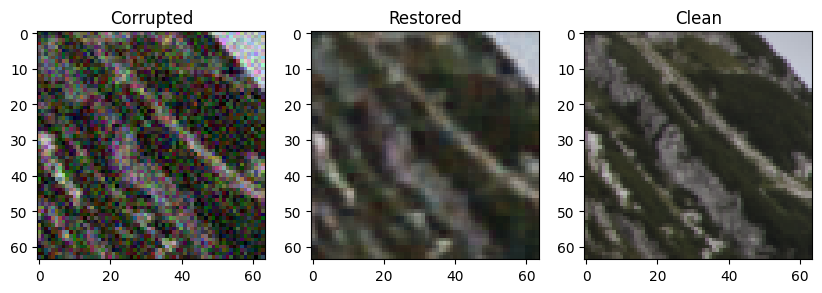

In [25]:
import matplotlib.pyplot as plt

noisy, clean = next(iter(val_loader))

noisy = noisy.to(device)

with torch.no_grad():
    restored = model(noisy)

noisy = noisy.cpu()
restored = restored.cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Corrupted")
plt.imshow(noisy[0].permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Restored")
plt.imshow(restored[0].permute(1,2,0))

plt.subplot(1,3,3)
plt.title("Clean")
plt.imshow(clean[0].permute(1,2,0))

plt.show()

In [21]:
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np

In [17]:
psnr_values = []

model.eval()

with torch.no_grad():
    for noisy, clean in val_loader:

        noisy = noisy.to(device)
        outputs = model(noisy)

        outputs = outputs.cpu().numpy()
        clean = clean.numpy()

        for i in range(outputs.shape[0]):
            value = psnr(clean[i], outputs[i], data_range=1)
            psnr_values.append(value)

print("Average PSNR:", np.mean(psnr_values))

Average PSNR: 27.012965179361302


In [18]:
from skimage.metrics import structural_similarity as ssim

In [19]:
ssim_values = []

for i in range(outputs.shape[0]):

    ssim_val = ssim(clean[i].transpose(1,2,0),
                    outputs[i].transpose(1,2,0),
                    data_range=1,
                    channel_axis=2)

    ssim_values.append(ssim_val)

print("Average SSIM:", np.mean(ssim_values))

Average SSIM: 0.75558835


In [20]:
torch.save(model.state_dict(), "/kaggle/working/simple_autoencoder_model.pth")

In [21]:
import torchvision.utils as vutils

vutils.save_image(restored[0], "/kaggle/working/restored_example1.png")

In [26]:
vutils.save_image(noisy[0], "/kaggle/working/corrupted.png")
vutils.save_image(clean[0], "/kaggle/working/clean.png")

In [22]:
results = {
    "model": "SimpleAutoencoder",
    "epochs": 10,
    "PSNR": 27.10,
    "ssim" : 0.755
}

print(results)

{'model': 'SimpleAutoencoder', 'epochs': 10, 'PSNR': 27.1, 'ssim': 0.755}


**model 2 : improved**

In [28]:
import torch
import torch.nn as nn

class ImprovedAutoencoder(nn.Module):
    
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, 2, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [29]:
model2 = ImprovedAutoencoder().to(device)
print("Model loaded on:", device)

Model loaded on: cuda


In [33]:
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [34]:
num_epochs = 20

for epoch in range(num_epochs):
    model2.train()
    running_loss = 0.0

    for noisy, clean in train_loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        outputs = model2(noisy)
        loss = criterion(outputs, clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.6f}")

Epoch [1/20], Loss: 0.007552
Epoch [2/20], Loss: 0.003075
Epoch [3/20], Loss: 0.002757
Epoch [4/20], Loss: 0.002576
Epoch [5/20], Loss: 0.002425
Epoch [6/20], Loss: 0.002320
Epoch [7/20], Loss: 0.002212
Epoch [8/20], Loss: 0.002146
Epoch [9/20], Loss: 0.002038
Epoch [10/20], Loss: 0.001972
Epoch [11/20], Loss: 0.001949
Epoch [12/20], Loss: 0.001899
Epoch [13/20], Loss: 0.001876
Epoch [14/20], Loss: 0.001837
Epoch [15/20], Loss: 0.001822
Epoch [16/20], Loss: 0.001806
Epoch [17/20], Loss: 0.001780
Epoch [18/20], Loss: 0.001761
Epoch [19/20], Loss: 0.001749
Epoch [20/20], Loss: 0.001736


In [35]:
model2.eval()

ImprovedAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)

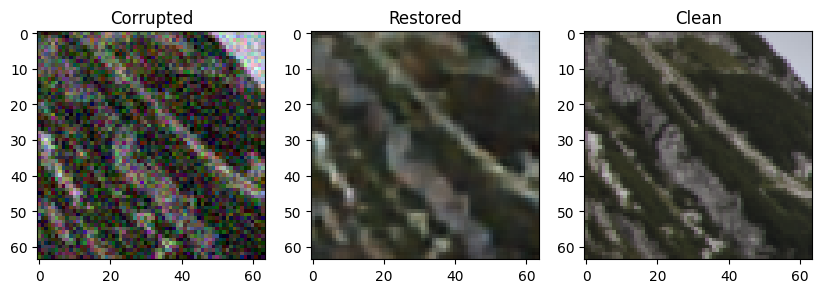

In [36]:
import matplotlib.pyplot as plt

noisy, clean = next(iter(val_loader))

noisy = noisy.to(device)

with torch.no_grad():
    restored = model2(noisy)

noisy = noisy.cpu()
restored = restored.cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Corrupted")
plt.imshow(noisy[0].permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Restored")
plt.imshow(restored[0].permute(1,2,0))

plt.subplot(1,3,3)
plt.title("Clean")
plt.imshow(clean[0].permute(1,2,0))

plt.show()

In [37]:
psnr_values = []

model2.eval()

with torch.no_grad():
    for noisy, clean in val_loader:

        noisy = noisy.to(device)
        outputs = model2(noisy)

        outputs = outputs.cpu().numpy()
        clean = clean.numpy()

        for i in range(outputs.shape[0]):
            value = psnr(clean[i], outputs[i], data_range=1)
            psnr_values.append(value)

print("Average PSNR:", np.mean(psnr_values))

Average PSNR: 28.50576342325185


In [38]:
from skimage.metrics import structural_similarity as ssim

In [41]:
ssim_values = []

for i in range(outputs.shape[0]):

    ssim_val = ssim(clean[i].transpose(1,2,0),
                    outputs[i].transpose(1,2,0),
                    data_range=1,
                    channel_axis=2)

    ssim_values.append(ssim_val)

print("Average SSIM:", np.mean(ssim_values))

Average SSIM: 0.81675977


In [42]:
torch.save(model2.state_dict(), "/kaggle/working/improved_autoencoder_model.pth")

In [43]:
import torchvision.utils as vutils

vutils.save_image(restored[0], "/kaggle/working/restored_example2.png")

In [44]:
results = {
    "model": "ImprovedAutoencoder",
    "epochs": 20,
    "PSNR": 28.50,
    "ssim": 0.816
}

print(results)

{'model': 'ImprovedAutoencoder', 'epochs': 20, 'PSNR': 28.5, 'ssim': 0.816}


**Model 3: DnCnn**

In [24]:
import torch
import torch.nn as nn

class DnCNN(nn.Module):

    def __init__(self, depth=17, channels=64):
        super(DnCNN, self).__init__()

        layers = []

        # First layer
        layers.append(nn.Conv2d(3, channels, 3, padding=1, bias=False))
        layers.append(nn.ReLU(inplace=True))

        # Middle layers
        for _ in range(depth - 2):
            layers.append(nn.Conv2d(channels, channels, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(channels))
            layers.append(nn.ReLU(inplace=True))

        # Last layer (predict noise)
        layers.append(nn.Conv2d(channels, 3, 3, padding=1, bias=False))

        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):

        predicted_noise = self.dncnn(x)

        # residual learning
        clean = x - predicted_noise

        return clean

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = DnCNN().to(device)

In [26]:
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [27]:
num_epochs = 25

for epoch in range(num_epochs):
    model1.train()
    running_loss = 0.0

    for noisy, clean in train_loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        outputs = model1(noisy)
        loss = criterion(outputs, clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.6f}")

Epoch [1/25], Loss: 0.007265
Epoch [2/25], Loss: 0.003609
Epoch [3/25], Loss: 0.001986
Epoch [4/25], Loss: 0.001279
Epoch [5/25], Loss: 0.001193
Epoch [6/25], Loss: 0.001099
Epoch [7/25], Loss: 0.001098
Epoch [8/25], Loss: 0.001027
Epoch [9/25], Loss: 0.001007
Epoch [10/25], Loss: 0.000986
Epoch [11/25], Loss: 0.000971
Epoch [12/25], Loss: 0.000960
Epoch [13/25], Loss: 0.000947
Epoch [14/25], Loss: 0.000936
Epoch [15/25], Loss: 0.000942
Epoch [16/25], Loss: 0.000923
Epoch [17/25], Loss: 0.000914
Epoch [18/25], Loss: 0.000922
Epoch [19/25], Loss: 0.000907
Epoch [20/25], Loss: 0.000903
Epoch [21/25], Loss: 0.000899
Epoch [22/25], Loss: 0.000895
Epoch [23/25], Loss: 0.000892
Epoch [24/25], Loss: 0.000889
Epoch [25/25], Loss: 0.000892


In [28]:
model1.eval()

DnCNN(
  (dncnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(64, 64, kernel_size

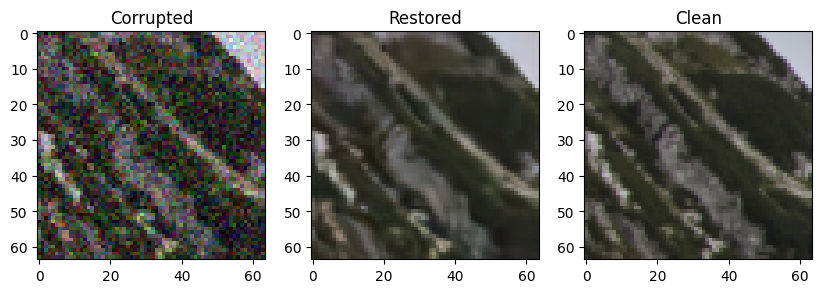

In [29]:
import matplotlib.pyplot as plt

noisy, clean = next(iter(val_loader))

noisy = noisy.to(device)

with torch.no_grad():
    restored = model1(noisy)

noisy = noisy.cpu()
restored = restored.cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Corrupted")
plt.imshow(noisy[0].permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Restored")
plt.imshow(restored[0].permute(1,2,0))

plt.subplot(1,3,3)
plt.title("Clean")
plt.imshow(clean[0].permute(1,2,0))

plt.show()

In [30]:
psnr_values = []

model1.eval()

with torch.no_grad():
    for noisy, clean in val_loader:

        noisy = noisy.to(device)
        outputs = model1(noisy)

        outputs = outputs.cpu().numpy()
        clean = clean.numpy()

        for i in range(outputs.shape[0]):
            value = psnr(clean[i], outputs[i], data_range=1)
            psnr_values.append(value)

print("Average PSNR:", np.mean(psnr_values))

Average PSNR: 31.375195925231395


In [31]:
from skimage.metrics import structural_similarity as ssim

In [32]:
ssim_values = []

for i in range(outputs.shape[0]):

    ssim_val = ssim(clean[i].transpose(1,2,0),
                    outputs[i].transpose(1,2,0),
                    data_range=1,
                    channel_axis=2)

    ssim_values.append(ssim_val)

print("Average SSIM:", np.mean(ssim_values))

Average SSIM: 0.89222634


In [33]:
torch.save(model1.state_dict(), "/kaggle/working/dncnn_model.pth")

In [34]:
import torchvision.utils as vutils

vutils.save_image(restored[0], "/kaggle/working/restored_dncnn.png")

In [35]:
results = {
    "model": "dnCnn",
    "epochs": 25,
    "PSNR": 31.37,
    "ssim": 0.892
}

print(results)

{'model': 'dnCnn', 'epochs': 25, 'PSNR': 31.37, 'ssim': 0.892}


**UNet Model**

In [15]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        return self.sigmoid(out)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model3 = UNet().to(device)
print("Model loaded on:", device)

Model loaded on: cuda


In [18]:
optimizer = torch.optim.Adam(model3.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [19]:
num_epochs = 25

for epoch in range(num_epochs):
    model3.train()
    running_loss = 0.0

    for noisy, clean in train_loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        outputs = model3(noisy)
        loss = criterion(outputs, clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.6f}")

Epoch [1/25], Loss: 0.002717
Epoch [2/25], Loss: 0.001302
Epoch [3/25], Loss: 0.001207
Epoch [4/25], Loss: 0.001142
Epoch [5/25], Loss: 0.001098
Epoch [6/25], Loss: 0.001042
Epoch [7/25], Loss: 0.001024
Epoch [8/25], Loss: 0.000993
Epoch [9/25], Loss: 0.000980
Epoch [10/25], Loss: 0.000955
Epoch [11/25], Loss: 0.000962
Epoch [12/25], Loss: 0.000937
Epoch [13/25], Loss: 0.000930
Epoch [14/25], Loss: 0.000927
Epoch [15/25], Loss: 0.000922
Epoch [16/25], Loss: 0.000913
Epoch [17/25], Loss: 0.000911
Epoch [18/25], Loss: 0.000905
Epoch [19/25], Loss: 0.000902
Epoch [20/25], Loss: 0.000901
Epoch [21/25], Loss: 0.000896
Epoch [22/25], Loss: 0.000893
Epoch [23/25], Loss: 0.000892
Epoch [24/25], Loss: 0.000892
Epoch [25/25], Loss: 0.000886


In [20]:
model3.eval()

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (poo

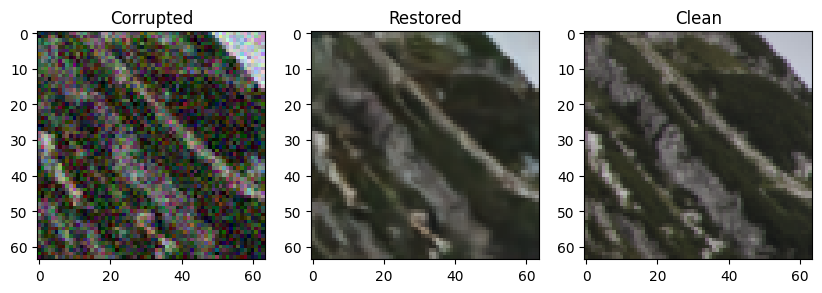

In [21]:
import matplotlib.pyplot as plt

noisy, clean = next(iter(val_loader))

noisy = noisy.to(device)

with torch.no_grad():
    restored = model3(noisy)

noisy = noisy.cpu()
restored = restored.cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Corrupted")
plt.imshow(noisy[0].permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Restored")
plt.imshow(restored[0].permute(1,2,0))

plt.subplot(1,3,3)
plt.title("Clean")
plt.imshow(clean[0].permute(1,2,0))

plt.show()

In [24]:
psnr_values = []

model3.eval()

with torch.no_grad():
    for noisy, clean in val_loader:

        noisy = noisy.to(device)
        outputs = model3(noisy)

        outputs = outputs.cpu().numpy()
        clean = clean.numpy()

        for i in range(outputs.shape[0]):
            value = psnr(clean[i], outputs[i], data_range=1)
            psnr_values.append(value)

print("Average PSNR:", np.mean(psnr_values))

Average PSNR: 31.258211838630963


In [26]:
torch.save(model3.state_dict(), "/kaggle/working/unet_model.pth")

In [27]:
import torchvision.utils as vutils

vutils.save_image(restored[0], "/kaggle/working/restored_example3.png")

In [30]:
from skimage.metrics import structural_similarity as ssim

In [31]:
ssim_values = []

for i in range(outputs.shape[0]):

    ssim_val = ssim(clean[i].transpose(1,2,0),
                    outputs[i].transpose(1,2,0),
                    data_range=1,
                    channel_axis=2)

    ssim_values.append(ssim_val)

print("Average SSIM:", np.mean(ssim_values))

Average SSIM: 0.90325516


In [32]:
results = {
    "model": "UNet",
    "epochs": 25,
    "PSNR": 31.26,
    "ssim": 0.903
}

print(results)

{'model': 'UNet', 'epochs': 25, 'PSNR': 31.26, 'ssim': 0.903}
